#### Install & Import Libraries

In [1]:
#!pip install yfinance

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize


### Collect Data

In [2]:
# Download adjusted close prices for the 4 tickers
portfolio_symbols = ["AAPL", "MSFT", "GOOGL", "TSLA"]
start_date = "2020-01-01"
end_date   = "2023-12-31"

raw = yf.download(portfolio_symbols, start=start_date, end=end_date,
                  auto_adjust=True, progress=False)["Close"]
raw.columns.name = None          # drop the 'Ticker' level name for cleaner display
raw = raw[portfolio_symbols]     # ensure consistent column order
print(f"Downloaded {len(raw)} trading days for {portfolio_symbols}")
display(raw.head())


Downloaded 1006 trading days for ['AAPL', 'MSFT', 'GOOGL', 'TSLA']


,AAPL,MSFT,GOOGL,TSLA
Date,,,,
2020-01-02,72.400528,152.158386,67.873024,28.684000
2020-01-03,71.696632,150.263748,67.517967,29.534000
2020-01-06,72.267937,150.652161,69.317596,30.102667
2020-01-07,71.928055,149.278549,69.183693,31.270666
2020-01-08,73.085091,151.656281,69.676117,32.809334


In [3]:
# portfolio_symbols already defined in the cell above
print("Symbols:", portfolio_symbols)


Symbols: ['AAPL', 'MSFT', 'GOOGL', 'TSLA']


In [4]:
# Use the DataFrame downloaded above directly (no CSV needed)
portfolio_data = raw.copy()
display(portfolio_data.tail())


,AAPL,MSFT,GOOGL,TSLA
Date,,,,
2023-12-22,191.609497,368.236603,140.330200,252.539993
2023-12-26,191.065140,368.315308,140.359940,256.609985
2023-12-27,191.164062,367.735229,139.219360,261.440002
2023-12-28,191.589661,368.924774,139.080505,253.179993
2023-12-29,190.550476,369.671844,138.544952,248.479996


### Exploratory Data Visualization

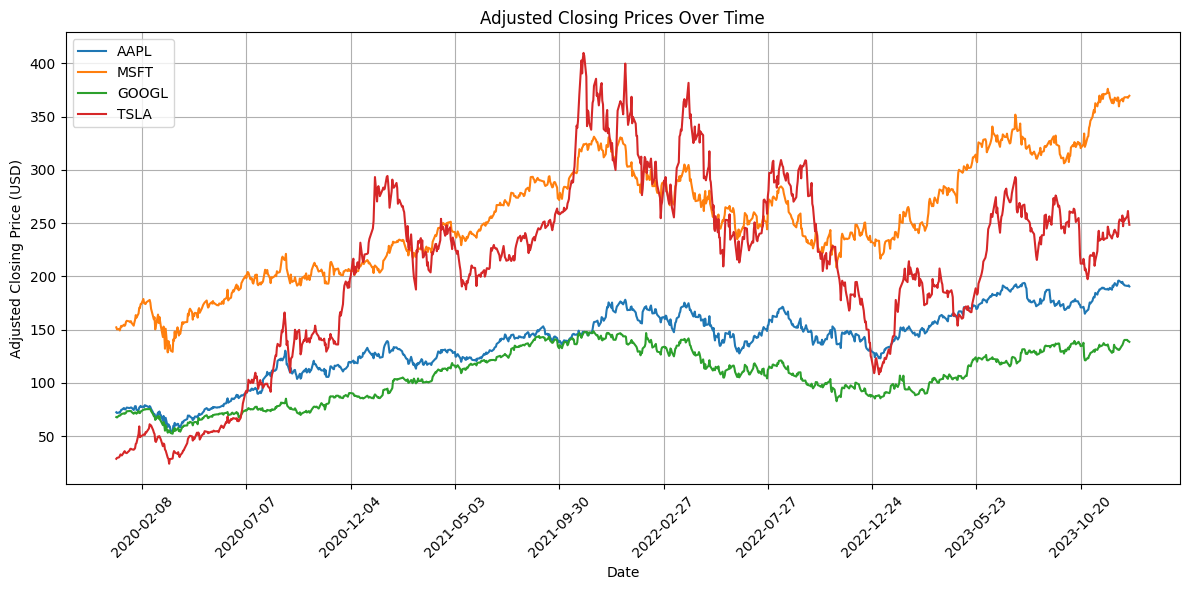

In [5]:
plt.figure(figsize=(12, 6))
for symbol in portfolio_symbols:
    series = portfolio_data[symbol].dropna()
    plt.plot(series.index, series.values, label=symbol)
plt.xlabel("Date")
plt.ylabel("Adjusted Closing Price (USD)")
plt.title("Adjusted Closing Prices Over Time")
plt.legend(loc='upper left')
plt.grid(True)
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(15))
plt.tight_layout()
plt.show()


### Section 1: Preprocess data

In [6]:
# --- Data Preprocessing ---
# 1. Drop rows where ALL prices are missing
prices = portfolio_data[portfolio_symbols].dropna(how='all')

# 2. Calculate simple pct returns, then log returns
simple_returns = prices.pct_change()

# FIX: replace inf/-inf (from zero-price edge cases) before dropping NaN
simple_returns.replace([np.inf, -np.inf], np.nan, inplace=True)
simple_returns.dropna(inplace=True)

# 3. Log returns  (used for all downstream calculations)
log_returns = np.log(1 + simple_returns)

# 4. Rolling statistics (20-day window)
rolling_mean = log_returns.rolling(20).mean()
rolling_std  = log_returns.rolling(20).std()

print("Preprocessed log returns shape:", log_returns.shape)
display(log_returns.head())


Preprocessed log returns shape: (1005, 4)


,AAPL,MSFT,GOOGL,TSLA
Date,,,,
2020-01-03,-0.009770,-0.012530,-0.005245,0.029203
2020-01-06,0.007937,0.002582,0.026305,0.019072
2020-01-07,-0.004714,-0.009160,-0.001934,0.038067
2020-01-08,0.015958,0.015803,0.007092,0.048033
2020-01-09,0.021019,0.012416,0.010443,-0.022189


### Section 2: Portfolio Metrics

In [7]:
# --- Section 1: Portfolio Metrics (equal-weight baseline) ---
n = len(portfolio_symbols)
eq_weights = np.array([1/n] * n)

mean_daily  = log_returns.mean()                        # daily mean log return per stock
cov_matrix  = log_returns.cov()                         # daily covariance matrix

port_return_daily = float(eq_weights @ mean_daily)      # scalar
port_vol_daily    = float(np.sqrt(eq_weights @ cov_matrix.values @ eq_weights))

# Annualise (×252 for return, ×√252 for volatility)
port_return_annual = port_return_daily * 252
port_vol_annual    = port_vol_daily    * np.sqrt(252)

daily_rf   = 0.03 / 252           # 3% annual → daily
annual_rf  = 0.03

# FIX: Sharpe computed with matching frequency (daily rf vs daily returns)
sharpe_daily  = (port_return_daily  - daily_rf)  / port_vol_daily
sharpe_annual = (port_return_annual - annual_rf) / port_vol_annual   # equivalent

metrics = {
    'Equal-Weight Portfolio (daily)': {
        'Return':        round(port_return_daily,  6),
        'Volatility':    round(port_vol_daily,     6),
        'Sharpe (daily)':round(sharpe_daily,       4),
    },
    'Equal-Weight Portfolio (annual)': {
        'Return':         round(port_return_annual, 4),
        'Volatility':     round(port_vol_annual,    4),
        'Sharpe (annual)':round(sharpe_annual,      4),
    },
}
print('Section 1: Portfolio Metrics')
display(pd.DataFrame(metrics).T)


Section 1: Portfolio Metrics


,Return,Volatility,Sharpe (daily),Sharpe (annual)
Equal-Weight Portfolio (daily),0.001176,0.02195,0.0482,NaN
Equal-Weight Portfolio (annual),0.296400,0.34850,NaN,0.7645


In [8]:
# Individual stock stats
stats = pd.DataFrame({
    'Mean Daily Log Return': log_returns.mean(),
    'Daily Volatility':      log_returns.std(),
    'Annual Return (approx)':log_returns.mean() * 252,
    'Annual Volatility':     log_returns.std()  * np.sqrt(252),
})
print('Individual Stock Statistics:')
display(stats.round(4))


Individual Stock Statistics:


,Mean Daily Log Return,Daily Volatility,Annual Return (approx),Annual Volatility
AAPL,0.0010,0.0211,0.2426,0.3355
MSFT,0.0009,0.0206,0.2226,0.3263
GOOGL,0.0007,0.0212,0.1789,0.3358
TSLA,0.0021,0.0429,0.5414,0.6811


### Section 3: Optimized Portfolio Weights

In [9]:
# --- Section 3: Sharpe-Maximising Optimisation ---
expected_returns = log_returns.mean()     # daily mean log returns (Series)
cov_matrix       = log_returns.cov()      # daily covariance matrix (DataFrame)
num_assets       = len(expected_returns)
daily_rf         = 0.03 / 252             # FIX: use daily rf, not annual

def neg_sharpe(weights):
    ret = float(expected_returns.values @ weights)
    vol = float(np.sqrt(weights @ cov_matrix.values @ weights))
    return -(ret - daily_rf) / vol

# FIX: proper scipy constraint dict (weights must sum to 1)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds      = [(0.0, 1.0)] * num_assets
w0          = np.array([1.0 / num_assets] * num_assets)

result = minimize(
    neg_sharpe, w0,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
)

w_opt         = result.x
ret_opt       = float(expected_returns.values @ w_opt)
vol_opt       = float(np.sqrt(w_opt @ cov_matrix.values @ w_opt))
sharpe_opt    = (ret_opt - daily_rf) / vol_opt

optimized_portfolio = {
    'Portfolio Weights':    w_opt,
    'Portfolio Return':     ret_opt,
    'Portfolio Volatility': vol_opt,
    'Sharpe Ratio':         sharpe_opt,
}
print('Optimisation successful:', result.success)
print(f'Weights sum: {w_opt.sum():.6f}')  # must be 1.0


Optimisation successful: True
Weights sum: 1.000000


In [10]:
# Summary of Sharpe-Maximising result
print('Optimized Portfolio Weights:')
for sym, w in zip(portfolio_symbols, w_opt):
    print(f'  {sym}: {w:.4f} ({w*100:.1f}%)')
print(f'\nDaily  Return:     {ret_opt:.6f}')
print(f'Annual Return:     {ret_opt*252:.4f}  ({ret_opt*252*100:.2f}%)')
print(f'Daily  Volatility: {vol_opt:.6f}')
print(f'Annual Volatility: {vol_opt*np.sqrt(252):.4f}  ({vol_opt*np.sqrt(252)*100:.2f}%)')
print(f'Daily  Sharpe:     {sharpe_opt:.4f}')
print(f'Annual Sharpe:     {sharpe_opt*np.sqrt(252):.4f}')  # annualise by ×√252


Optimized Portfolio Weights:
  AAPL: 0.3223 (32.2%)
  MSFT: 0.2519 (25.2%)
  GOOGL: 0.0000 (0.0%)
  TSLA: 0.4258 (42.6%)

Daily  Return:     0.001448
Annual Return:     0.3648  (36.48%)
Daily  Volatility: 0.026123
Annual Volatility: 0.4147  (41.47%)
Daily  Sharpe:     0.0509
Annual Sharpe:     0.8073


In [11]:
# Already printed in cell above – kept as display check
optimized_weights = w_opt
print('Weights check (must sum to 1.0):', round(optimized_weights.sum(), 8))


Weights check (must sum to 1.0): 1.0


### Portfolio Allocation Table

In [12]:
print('\nSection 4: Portfolio Allocation Table')
allocation_df = pd.DataFrame(
    {'Allocation': w_opt, 'Allocation (%)': w_opt * 100},
    index=portfolio_symbols
).round(4)
display(allocation_df)



Section 4: Portfolio Allocation Table


,Allocation,Allocation (%)
AAPL,0.3223,32.2287
MSFT,0.2519,25.1931
GOOGL,0.0000,0.0000
TSLA,0.4258,42.5782


### Portfolio Allocation Pie Chart

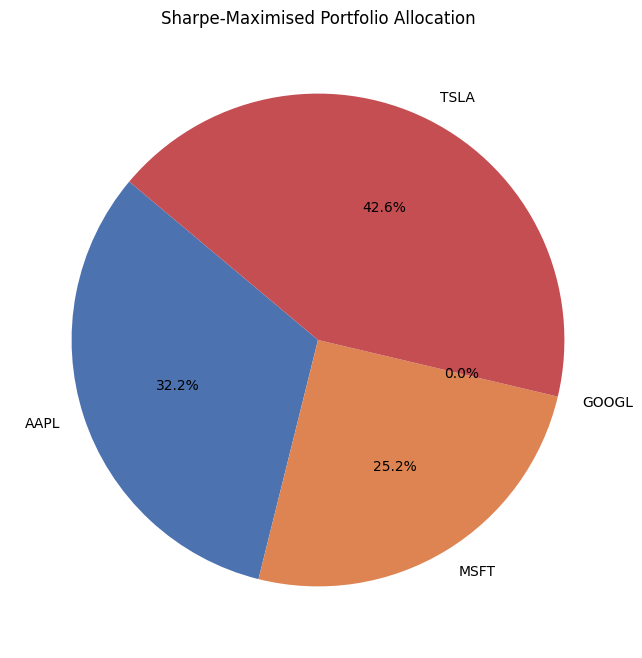

In [13]:
plt.figure(figsize=(8, 8))
plt.pie(w_opt, labels=portfolio_symbols, autopct='%1.1f%%', startangle=140,
        colors=['#4C72B0','#DD8452','#55A868','#C44E52'])
plt.title('Sharpe-Maximised Portfolio Allocation')
plt.show()


=== Strategy Comparison ===


,Sharpe-Max,Risk Parity
Weights,"{'AAPL': 0.3223, 'MSFT': 0.2519, 'GOOGL': 0.0,...","{'AAPL': 0.2754, 'MSFT': 0.2802, 'GOOGL': 0.28..."
Annual Return,0.3648,0.2668
Annual Volatility,0.4147,0.3256
Annual Sharpe,0.8073,0.7274


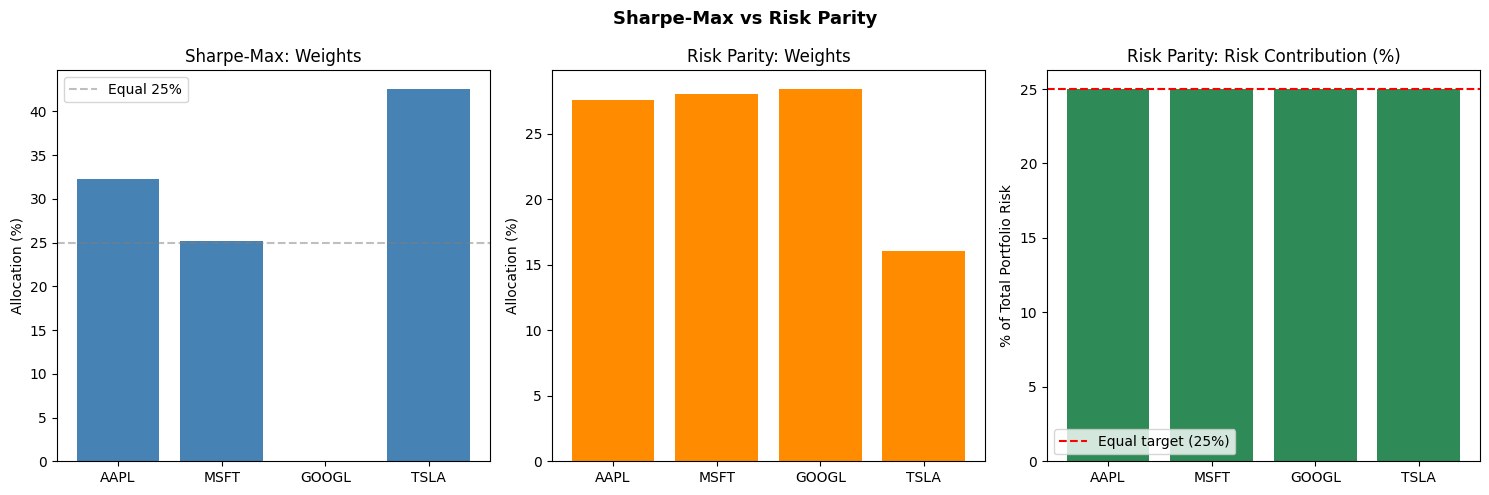

In [14]:
# --- Risk Parity Optimisation ---

def risk_contributions(w, cov):
    """Marginal Risk Contribution (MRC) vector."""
    port_vol = np.sqrt(w @ cov @ w)
    return w * (cov @ w) / port_vol

def rp_objective(w, cov):
    """Minimise pairwise squared differences of MRCs."""
    rc = risk_contributions(w, cov)
    return sum((rc[i] - rc[j])**2
               for i in range(len(w)) for j in range(i+1, len(w)))

cov_arr = cov_matrix.values.astype(float)
rp_res  = minimize(
    rp_objective, w0,
    args=(cov_arr,),
    method='SLSQP',
    bounds=[(1e-6, 1.0)] * num_assets,
    constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}),
    options={'ftol': 1e-12, 'maxiter': 2000},
)
w_rp = rp_res.x
rc   = risk_contributions(w_rp, cov_arr)
vol_rp = np.sqrt(w_rp @ cov_arr @ w_rp)

# --- Comparison Table ---
comparison = pd.DataFrame({
    'Sharpe-Max': {
        'Weights':           dict(zip(portfolio_symbols, w_opt.round(4))),
        'Annual Return':     round(ret_opt * 252, 4),
        'Annual Volatility': round(vol_opt * np.sqrt(252), 4),
        'Annual Sharpe':     round(sharpe_opt * np.sqrt(252), 4),
    },
    'Risk Parity': {
        'Weights':           dict(zip(portfolio_symbols, w_rp.round(4))),
        'Annual Return':     round((expected_returns.values @ w_rp) * 252, 4),
        'Annual Volatility': round(vol_rp * np.sqrt(252), 4),
        'Annual Sharpe':     round(((expected_returns.values @ w_rp) - daily_rf) / vol_rp * np.sqrt(252), 4),
    },
})
print('=== Strategy Comparison ===')
display(comparison)

# --- Charts ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sharpe-Max weights
axes[0].bar(portfolio_symbols, w_opt * 100, color='steelblue')
axes[0].set_title('Sharpe-Max: Weights')
axes[0].set_ylabel('Allocation (%)')
axes[0].axhline(25, color='grey', linestyle='--', alpha=0.5, label='Equal 25%')
axes[0].legend()

# Risk Parity weights
axes[1].bar(portfolio_symbols, w_rp * 100, color='darkorange')
axes[1].set_title('Risk Parity: Weights')
axes[1].set_ylabel('Allocation (%)')

# Risk Parity – actual risk contributions
rc_pct = rc / rc.sum() * 100
axes[2].bar(portfolio_symbols, rc_pct, color='seagreen')
axes[2].set_title('Risk Parity: Risk Contribution (%)')
axes[2].set_ylabel('% of Total Portfolio Risk')
axes[2].axhline(25, color='red', linestyle='--', label='Equal target (25%)')
axes[2].legend()

plt.suptitle('Sharpe-Max vs Risk Parity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


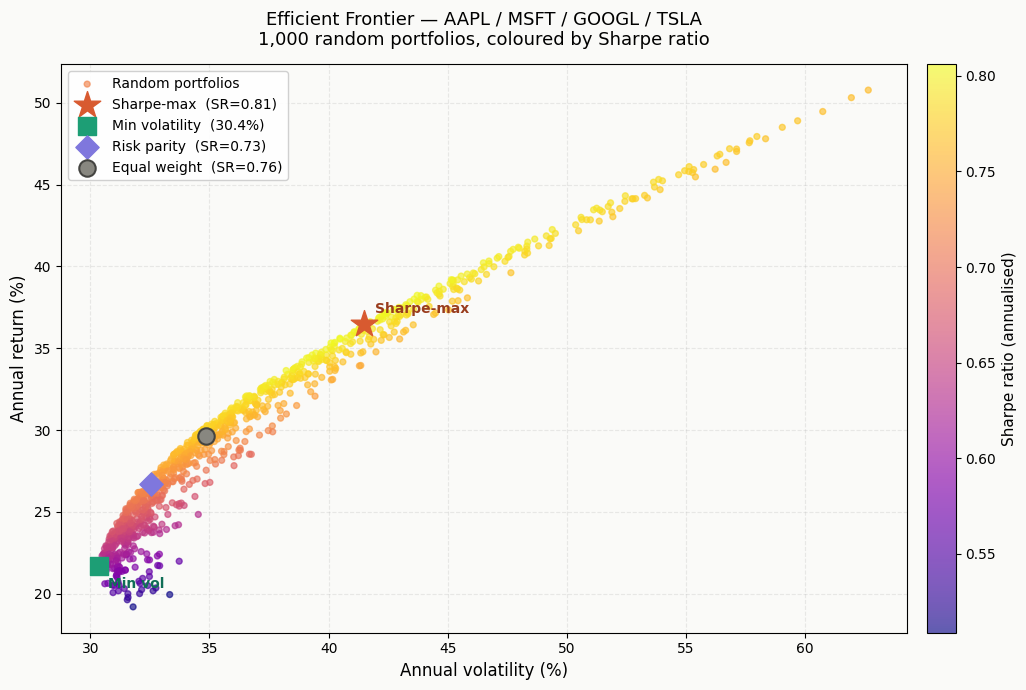

Asset,AAPL,MSFT,GOOGL,TSLA,Ann. Return,Ann. Vol,Sharpe
Sharpe-max,0.3223,0.2519,0.0000,0.4258,36.48%,41.47%,0.807
Risk Parity,0.2754,0.2802,0.2841,0.1603,26.68%,32.56%,0.727
Equal weight,0.2500,0.2500,0.2500,0.2500,29.64%,34.85%,0.764


In [15]:
# ── Efficient Frontier ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

N_PORTFOLIOS = 1000
num_assets   = len(portfolio_symbols)

# Storage
ef_returns  = np.zeros(N_PORTFOLIOS)
ef_vols     = np.zeros(N_PORTFOLIOS)
ef_sharpes  = np.zeros(N_PORTFOLIOS)
ef_weights  = np.zeros((N_PORTFOLIOS, num_assets))

mu  = expected_returns.values          # daily
cov = cov_matrix.values                # daily
DAILY_RF = 0.03 / 252

# Sample 1,000 random weight vectors via Dirichlet (uniform on the simplex)
np.random.seed(42)
for i in range(N_PORTFOLIOS):
    w = np.random.dirichlet(np.ones(num_assets))
    ret  = float(mu @ w)
    vol  = float(np.sqrt(w @ cov @ w))
    ef_weights[i]  = w
    ef_returns[i]  = ret  * 252              # annualise
    ef_vols[i]     = vol  * np.sqrt(252)
    ef_sharpes[i]  = (ret - DAILY_RF) / vol  * np.sqrt(252)

# ── Special portfolios ───────────────────────────────────────────────────────
# (reuse w_opt and w_rp from previous cells)
def port_stats(w):
    ret = float(mu @ w) * 252
    vol = float(np.sqrt(w @ cov @ w)) * np.sqrt(252)
    sr  = (ret - 0.03) / vol
    return ret, vol, sr

sharpe_ret, sharpe_vol, sharpe_sr = port_stats(w_opt)
rp_ret,     rp_vol,     rp_sr     = port_stats(w_rp)

eq_w = np.array([1/num_assets] * num_assets)
eq_ret, eq_vol, eq_sr = port_stats(eq_w)

# Min-vol portfolio (lowest volatility in the sample — good enough proxy)
min_idx = np.argmin(ef_vols)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#fafaf8')
ax.set_facecolor('#fafaf8')

sc = ax.scatter(
    ef_vols * 100, ef_returns * 100,
    c=ef_sharpes, cmap='plasma',
    s=18, alpha=0.65, zorder=2,
    label='Random portfolios'
)
cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('Sharpe ratio (annualised)', fontsize=11)

# Sharpe-max star
ax.scatter(sharpe_vol*100, sharpe_ret*100,
           marker='*', s=400, color='#D85A30', zorder=5,
           label=f'Sharpe-max  (SR={sharpe_sr:.2f})')
ax.annotate('Sharpe-max', xy=(sharpe_vol*100, sharpe_ret*100),
            xytext=(8, 8), textcoords='offset points',
            fontsize=10, color='#993C1D', fontweight='bold')

# Min-vol square
ax.scatter(ef_vols[min_idx]*100, ef_returns[min_idx]*100,
           marker='s', s=180, color='#1D9E75', zorder=5,
           label=f'Min volatility  ({ef_vols[min_idx]*100:.1f}%)')
ax.annotate('Min vol', xy=(ef_vols[min_idx]*100, ef_returns[min_idx]*100),
            xytext=(6, -16), textcoords='offset points',
            fontsize=10, color='#0F6E56', fontweight='bold')

# Risk Parity diamond
ax.scatter(rp_vol*100, rp_ret*100,
           marker='D', s=140, color='#7F77DD', zorder=5,
           label=f'Risk parity  (SR={rp_sr:.2f})')

# Equal-weight circle
ax.scatter(eq_vol*100, eq_ret*100,
           marker='o', s=140, color='#888780', zorder=5,
           edgecolors='#444441', linewidths=1.5,
           label=f'Equal weight  (SR={eq_sr:.2f})')

ax.set_xlabel('Annual volatility (%)', fontsize=12)
ax.set_ylabel('Annual return (%)',     fontsize=12)
ax.set_title('Efficient Frontier — AAPL / MSFT / GOOGL / TSLA\n'
             '1,000 random portfolios, coloured by Sharpe ratio',
             fontsize=13, pad=14)
ax.legend(fontsize=10, framealpha=0.9, loc='upper left')
ax.grid(True, alpha=0.25, linestyle='--')
plt.tight_layout()
plt.savefig('efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

# Weight table for the 3 key portfolios
wt = pd.DataFrame({
    'Sharpe-max':  w_opt.round(4),
    'Risk Parity': w_rp.round(4),
    'Equal weight':eq_w.round(4),
}, index=portfolio_symbols).T
wt.columns.name = 'Asset'
wt['Ann. Return'] = [f'{sharpe_ret*100:.2f}%', f'{rp_ret*100:.2f}%', f'{eq_ret*100:.2f}%']
wt['Ann. Vol']    = [f'{sharpe_vol*100:.2f}%', f'{rp_vol*100:.2f}%', f'{eq_vol*100:.2f}%']
wt['Sharpe']      = [f'{sharpe_sr:.3f}',       f'{rp_sr:.3f}',       f'{eq_sr:.3f}']
display(wt)